To take a closer look at spline interpolation and plot the interpolated curve. From discussion with Prof Lan on 7/7/2026.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
from scipy.interpolate import make_interp_spline, PchipInterpolator

def find_cliff_hdist(df, threshold):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Find the first index where reliability drops below threshold
    below_threshold = df_sorted[df_sorted['Reliability'] < threshold]
    
    if below_threshold.empty:
        # No point drops below threshold, return the max horizontal distance
        return df_sorted['Horizontal_Distance'].max()
    
    # Return the horizontal distance of the first point below threshold
    return below_threshold['Horizontal_Distance'].iloc[0]

def find_cliff_hdist_spline_interp(df, threshold, k_points = 5):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.
    Spline interpolation: We use spline interp to find the cliff point with a finer resolution of 1 m.
    Interpolation is first used to find the reliability at a resolution of 1 m before finding the cliff point.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).
    k_points (int): The number of nearest points to use for finding the reliability at finer resolution.

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Create a finer resolution of horizontal distances (1 m)
    hdist_fine = np.arange(df_sorted['Horizontal_Distance'].min(), df_sorted['Horizontal_Distance'].max() + 1, 1)
    # Interpolate reliability at finer resolution using k-nearest neighbors but only for the points not already in df_sorted
    for h in hdist_fine:
        if h in df_sorted['Horizontal_Distance'].values:
            pred = df_sorted[df_sorted['Horizontal_Distance'] == h]['Reliability'].values[0]
        else:
            # Find the k nearest points in df_sorted
            distances = np.abs(df_sorted['Horizontal_Distance'] - h)
            nearest_indices = np.argpartition(distances, kth=k_points - 1)[:k_points]
            nearest_reliabilities = df_sorted.loc[nearest_indices, 'Reliability']
            nearest_hdist = df_sorted.loc[nearest_indices, 'Horizontal_Distance']
            
            # Perform localized interpolation using the nearest points
            x_local = nearest_hdist.values
            y_local = nearest_reliabilities.values
            # Spline requires sorted x
            order = np.argsort(x_local)
            x_local = x_local[order]
            y_local = y_local[order]
            if len(x_local) == 1:
                pred = y_local[0]
            elif len(x_local) == 2:
                # Linear interpolation fallback
                pred = np.interp(float(h), x_local, y_local)
            else:
                # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
                k = 2 if len(x_local) == 3 else 3
                spline = make_interp_spline(x_local, y_local, k=k)
                # Keep local behavior; avoid extrapolation outside local window
                h_eval = float(np.clip(h, x_local.min(), x_local.max()))
                pred = float(spline(h_eval))
        
        # If predicted reliability is less than threshold, we can stop early since we are only interested in the cliff point
        if pred < threshold:
            return h - 1  # Return the last horizontal distance before dropping below threshold
        
    #         reliability_fine.append(float(np.clip(pred, 0.0, 1.0)))  # Ensure reliability is between 0 and 1
    
    # df_fine = pd.DataFrame({'Horizontal_Distance': hdist_fine, 'Reliability': reliability_fine})

    # # Find the first index where reliability drops below threshold in the finer resolution
    # below_threshold = df_fine[df_fine['Reliability'] < threshold]
    
    # if below_threshold.empty:
    #     # No point drops below threshold, return the max horizontal distance
    #     return df_fine['Horizontal_Distance'].max()
    
    # # Return the horizontal distance of the first point below threshold
    # return below_threshold['Horizontal_Distance'].iloc[0]

def interp_reliability(df, k_points = 3):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.
    Spline interpolation: We use spline interp to find the cliff point with a finer resolution of 1 m.
    Interpolation is first used to find the reliability at a resolution of 1 m before finding the cliff point.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).
    k_points (int): The number of nearest points to use for finding the reliability at finer resolution.

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Create a finer resolution of horizontal distances (1 m)
    hdist_fine = np.arange(df_sorted['Horizontal_Distance'].min(), df_sorted['Horizontal_Distance'].max() + 1, 1)
    # Interpolate reliability at finer resolution using k-nearest neighbors but only for the points not already in df_sorted
    reliability_fine = []
    for h in hdist_fine:
        if h in df_sorted['Horizontal_Distance'].values:
            pred = df_sorted[df_sorted['Horizontal_Distance'] == h]['Reliability'].values[0]
        else:
            # Find the k nearest points in df_sorted
            distances = np.abs(df_sorted['Horizontal_Distance'] - h)
            nearest_indices = np.argpartition(distances, kth=k_points - 1)[:k_points]
            nearest_reliabilities = df_sorted.loc[nearest_indices, 'Reliability']
            nearest_hdist = df_sorted.loc[nearest_indices, 'Horizontal_Distance']
            
            # Perform localized interpolation using the nearest points
            x_local = nearest_hdist.values
            y_local = nearest_reliabilities.values
            # Spline requires sorted x
            order = np.argsort(x_local)
            x_local = x_local[order]
            y_local = y_local[order]
            if len(x_local) == 1:
                pred = y_local[0]
            elif len(x_local) == 2:
                # Linear interpolation fallback
                pred = np.interp(float(h), x_local, y_local)
            else:
                # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
                k = 2 if len(x_local) == 3 else 3
                spline = make_interp_spline(x_local, y_local, k=k)
                # Keep local behavior; avoid extrapolation outside local window
                h_eval = float(np.clip(h, x_local.min(), x_local.max()))
                pred = float(spline(h_eval))
        
        reliability_fine.append(float(np.clip(pred, 0.0, 1.0)))  # Ensure reliability is between 0 and 1
    
    df_fine = pd.DataFrame({'Horizontal_Distance': hdist_fine, 'Reliability': reliability_fine})
    return df_fine

## Get spline interp curve

In [2]:
# Localized cubic spline interpolation with 4 nearest points.
# Update: For each combination of USI and MCS, we consider the range of height from 60 m to the height in the TRAINING data that has a cliff dist that is non-zero.

# -------------------------------------------------
# Assumes find_cliff_hdist(df, threshold) exists
# -------------------------------------------------

def add_reliability(df: pd.DataFrame) -> pd.DataFrame:
    if "Num_Sent" in df.columns and "Num_Reliable" in df.columns:
        df["Reliability"] = df["Num_Reliable"] / df["Num_Sent"]
    elif all(c in df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
        denom = df["Num_Reliable"] + df["Num_Delay_Excd"] + df["Num_Fail_Other"]
        df["Reliability"] = df["Num_Reliable"] / denom
    else:
        raise ValueError("Required columns for Reliability not found.")
    return df

def combo_subset(df: pd.DataFrame, usi: float, bitrate: float, height: float) -> pd.DataFrame:
    # isclose is safer than exact float equality
    m_usi = np.isclose(df["UAV_Sending_Interval"].to_numpy(dtype=float), float(usi))
    m_bitrate = np.isclose(df["Bitrate"].to_numpy(dtype=float), float(bitrate))
    m_height = np.isclose(df["Height"].to_numpy(dtype=float), float(height))
    return df.loc[m_usi & m_bitrate & m_height]

def local_spline_predict(train_heights, train_targets, test_height, k_neighbors=3):
    """
    Predict at test_height using a local spline fitted ONLY on k nearest train points.
    Returns np.nan if prediction cannot be made.
    """
    x = np.asarray(train_heights, dtype=float)
    y = np.asarray(train_targets, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if x.size == 0:
        return np.nan

    # Deduplicate x if needed
    xy = (
        pd.DataFrame({"x": x, "y": y})
        .groupby("x", as_index=False)["y"]
        .mean()
        .sort_values("x")
    )
    x = xy["x"].to_numpy(dtype=float)
    y = xy["y"].to_numpy(dtype=float)

    n = min(int(k_neighbors), len(x))
    if n == 0:
        return np.nan

    # Pick k nearest points in height dimension
    dist = np.abs(x - float(test_height))
    idx = np.argpartition(dist, kth=n - 1)[:n]
    x_local = x[idx]
    y_local = y[idx]

    # Spline requires sorted x
    order = np.argsort(x_local)
    x_local = x_local[order]
    y_local = y_local[order]

    if len(x_local) == 1:
        pred = y_local[0]
    elif len(x_local) == 2:
        # Linear interpolation fallback
        pred = np.interp(float(test_height), x_local, y_local)
    else:
        # With 3 points, quadratic spline (k=2), else cubic spline (k=3)
        k = 2 if len(x_local) == 3 else 3
        spline = make_interp_spline(x_local, y_local, k=k)
        # Keep local behavior; avoid extrapolation outside local window
        h_eval = float(np.clip(test_height, x_local.min(), x_local.max()))
        pred = float(spline(h_eval))

    return float(max(pred, 0.0))  # optional clamp to non-negative

# -----------------------------
# Config
# -----------------------------
link = "Downlink"  # "Downlink", "Uplink", "Video"
USI = 66.7
BITRATE = 39
TRAIN_HEIGHT = [60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]
TEST_HEIGHT = [68, 82, 98, 112, 128, 142, 158, 172, 188, 202, 218, 232, 248, 262, 278, 292]
THRESHOLD = 0.99
K_NEIGHBORS = 4
CLIFF_THRESHOLD = 0 # Threshold for minimum cliff hdist to consider, in m

train_dataset_file_path = (
    f"C:\\Users\\reube\\OneDrive\\Documents\\PhD\\Journal2\\"
    f"Dataset_NP100000_DJISpark\\refined_train_0.1m_dataset_processed\\{link}_Reliability.csv"
)
test_dataset_file_path = (
    f"C:\\Users\\reube\\OneDrive\\Documents\\PhD\\Journal2\\"
    f"Dataset_NP100000_DJISpark\\refined_test_0.1m_dataset_processed\\{link}_Reliability.csv"
)

# -----------------------------
# Load and prepare data
# -----------------------------
train_df = add_reliability(pd.read_csv(train_dataset_file_path))
test_df = add_reliability(pd.read_csv(test_dataset_file_path))

# Find cliff distances for TRAIN_HEIGHT
train_curves = {}
x_train = []
y_train = []
for h in TRAIN_HEIGHT:
    subset = combo_subset(train_df, USI, BITRATE, h)
    cliff_hdist = find_cliff_hdist(subset, threshold=THRESHOLD)
    x_train.append(float(h))
    y_train.append(float(cliff_hdist))

x_train = np.array(x_train, dtype=float)
y_train = np.array(y_train, dtype=float)

# UPDATE: We exclude heights where cliff distance is below CLIFF_THRESHOLD, beyond this height the prediction is just zero
# First, find the index of height right before where cliff distance becomes zero (if any)
low_cliff_indices = np.where(y_train <= CLIFF_THRESHOLD)[0]
if low_cliff_indices.size > 0:
    low_cliff_height = x_train[low_cliff_indices[0]]
    print(f"USI={USI}, Bitrate={BITRATE}: Excluding heights above {low_cliff_height} m due to low cliff distance (<= {CLIFF_THRESHOLD} m).")
    # Exclude points above this height
    mask = x_train <= low_cliff_height
    x_train = x_train[mask]
    y_train = y_train[mask]

# Find cliff distances for TEST_HEIGHT
gt_list = []
for h in TEST_HEIGHT:
    if h > x_train.max():
        continue
    subset_t = combo_subset(test_df, USI, BITRATE, h)
    gt_list.append(float(find_cliff_hdist(subset_t, threshold=THRESHOLD)))

# Find localized spline interpolation for INTERP_HEIGHT
INTERP_HEIGHT = np.arange(60, 285, 1)  # Interpolation heights from 60 m to max height at 1 m resolution
interp_results = []
for h in INTERP_HEIGHT:
    pred = local_spline_predict(
        x_train,
        y_train,
        test_height=float(h),
        k_neighbors=K_NEIGHBORS
    )
    interp_results.append(pred)

print(f"Generated {len(interp_results)} predictions.")

USI=66.7, Bitrate=39: Excluding heights above 300.0 m due to low cliff distance (<= 0 m).
Generated 225 predictions.


## Plot spline interp curve

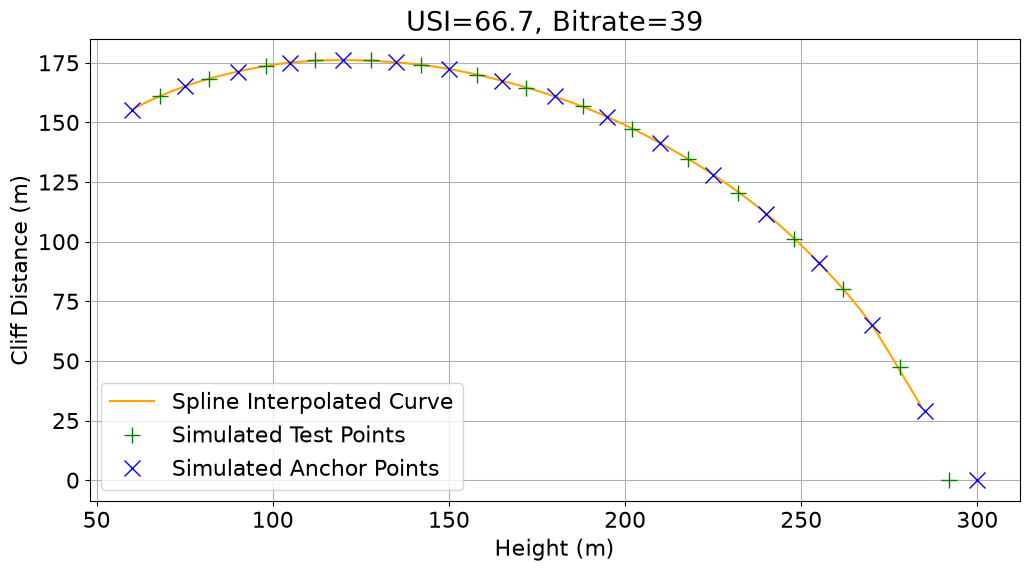

In [3]:
# Plot interp_results vs INTERP_HEIGHT, gt_list vs TEST_HEIGHT, and x_train vs y_train
plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 16})
plt.plot(INTERP_HEIGHT, interp_results, label="Spline Interpolated Curve", color='orange')
plt.plot(TEST_HEIGHT, gt_list, '+', label="Simulated Test Points", markersize = 12, color='green') #Increase marker size
plt.plot(x_train, y_train, 'x', label="Simulated Anchor Points", markersize = 12, color='blue')
plt.xlabel("Height (m)")
plt.ylabel("Cliff Distance (m)")
plt.title(f"USI={USI}, Bitrate={BITRATE}")
plt.legend()
plt.grid(True)
plt.show()